In [14]:
#ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 01:
print("ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 01:\n")
# Importing necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Load the Boston Housing dataset
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()
# Display the shape of the data
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
# Function to create and train the model
def create_and_train_model(X_train_scaled, y_train, X_test_scaled, y_test):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    # Model compilation
    model.compile(optimizer='adam', loss='mean_squared_error')
    # Model training
    model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)
    # Model evaluation
    loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    return loss
# StandardScaler
scaler_standard = StandardScaler()
X_train_scaled_standard = scaler_standard.fit_transform(X_train)
X_test_scaled_standard = scaler_standard.transform(X_test)
loss_standard = create_and_train_model(X_train_scaled_standard, y_train, X_test_scaled_standard, y_test)
print(f"\n--- Using {scaler_name} ---")
print(f"Mean Squared Error with StandardScaler: {loss_standard:.4f}")
# MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_scaled_minmax = scaler_minmax.fit_transform(X_train)
X_test_scaled_minmax = scaler_minmax.transform(X_test)
loss_minmax = create_and_train_model(X_train_scaled_minmax, y_train, X_test_scaled_minmax, y_test)
print(f"\n--- Using {scaler_name} ---")
print(f"Mean Squared Error with MinMaxScaler: {loss_minmax:.4f}")

ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 01:

Training data shape: (404, 13)
Test data shape: (102, 13)


C:\Users\ABDUL RAFAY\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Using MinMaxScaler ---
Mean Squared Error with StandardScaler: 20.6180


C:\Users\ABDUL RAFAY\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Using MinMaxScaler ---
Mean Squared Error with MinMaxScaler: 25.5620


ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 02:

Training data shape: (404, 13)
Test data shape: (102, 13)
Mean Squared Error on Raw Data: 40.1718


C:\Users\ABDUL RAFAY\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mean Squared Error with StandardScaler: 20.9159


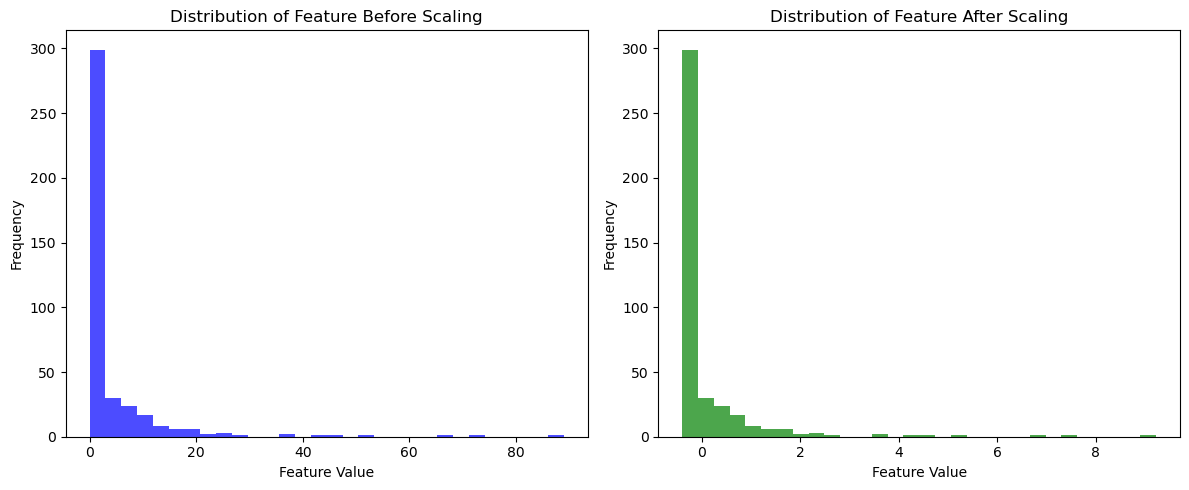

In [15]:
#ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 02:
print("ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 02:\n")
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler
# Load the Boston Housing dataset
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()
# Display the shape of the data
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
# Function to create and train the model
def create_and_train_model(X_train_data, y_train, X_test_data, y_test):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train_data.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1))
    # Model compilation
    model.compile(optimizer='adam', loss='mean_squared_error')
    # Model training
    model.fit(X_train_data, y_train, epochs=100, batch_size=32, verbose=0)
    # Model evaluation
    loss = model.evaluate(X_test_data, y_test, verbose=0)
    return loss
# Train model on raw (unscaled) data
loss_raw = create_and_train_model(X_train, y_train, X_test, y_test)
print(f"Mean Squared Error on Raw Data: {loss_raw:.4f}")
# Normalize the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train model on scaled data
loss_scaled = create_and_train_model(X_train_scaled, y_train, X_test_scaled, y_test)
print(f"Mean Squared Error with StandardScaler: {loss_scaled:.4f}")
# Visualize the distribution of a feature before and after scaling
feature_index = 0  # Change this index to visualize different features
plt.figure(figsize=(12, 5))
# Before scaling
plt.subplot(1, 2, 1)
plt.hist(X_train[:, feature_index], bins=30, alpha=0.7, color='blue')
plt.title('Distribution of Feature Before Scaling')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
# After scaling
plt.subplot(1, 2, 2)
plt.hist(X_train_scaled[:, feature_index], bins=30, alpha=0.7, color='green')
plt.title('Distribution of Feature After Scaling')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [16]:
#ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 03:
print("ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 03:\n")
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load California housing dataset
data = fetch_california_housing()
X, y = data.data, data.target
print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
# Normalize the data using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Build the model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
# Train the model
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)
# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Mean Squared Error on California Housing Test Data:", loss)
# Optional: Predict and display some results
predictions = model.predict(X_test_scaled[:5])
print("\nFirst 5 Predictions:", predictions.flatten())
print("Actual Values:", y_test[:5])

ABDUL RAFAY / 2022F-BSE-197 / LAB 06 / TASK 03:

Dataset shape: (20640, 8)
Target shape: (20640,)
Training data shape: (16512, 8)
Test data shape: (4128, 8)


C:\Users\ABDUL RAFAY\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mean Squared Error on California Housing Test Data: 0.2908402383327484
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

First 5 Predictions: [0.62995553 0.8061181  5.8120184  2.6645486  2.754452  ]
Actual Values: [0.477   0.458   5.00001 2.186   2.78   ]
